In [1]:
from google.colab import files

uploaded = files.upload()

Saving UNSW-NB15.zip.zip to UNSW-NB15.zip.zip


In [2]:
import os

print(os.listdir())

['.config', 'UNSW-NB15.zip.zip', 'sample_data']


In [3]:
# ============================================================
# STEP 1: Dataset Loading and Initial Inspection
# Unsupervised Network Threat Intelligence and Anomaly Detection System
# Dataset: UNSW-NB15 (Kaggle ZIP)
# ============================================================

import os
import zipfile
import pandas as pd

# ------------------------------------------------------------
# 1. Extract the ZIP file
# ------------------------------------------------------------
zip_path = "UNSW-NB15.zip.zip"          # <-- update with your actual zip filename/path
extract_dir = "unsw_nb15_extracted"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Extracted '{zip_path}' to '{extract_dir}'\n")

# ------------------------------------------------------------
# 2. Display all extracted filenames
# ------------------------------------------------------------
extracted_files = []
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        extracted_files.append(os.path.join(root, file))

print("Extracted files:")
for f in extracted_files:
    print(" -", f)
print()

# ------------------------------------------------------------
# 3. Automatically identify CSV or Parquet dataset files
# ------------------------------------------------------------
csv_files = [f for f in extracted_files if f.lower().endswith(".csv")]
parquet_files = [f for f in extracted_files if f.lower().endswith(".parquet")]

print(f"Found {len(csv_files)} CSV file(s):")
for f in csv_files:
    print(" -", f)

print(f"\nFound {len(parquet_files)} Parquet file(s):")
for f in parquet_files:
    print(" -", f)
print()

# ------------------------------------------------------------
# 4. Load the appropriate dataset file(s)
# ------------------------------------------------------------
dataframes = []

if csv_files:
    for f in csv_files:
        df_temp = pd.read_csv(f, low_memory=False)
        dataframes.append(df_temp)
        print(f"Loaded CSV: {f}  -> shape {df_temp.shape}")
elif parquet_files:
    for f in parquet_files:
        df_temp = pd.read_parquet(f)
        dataframes.append(df_temp)
        print(f"Loaded Parquet: {f}  -> shape {df_temp.shape}")
else:
    raise FileNotFoundError("No CSV or Parquet files found in the extracted ZIP.")

# If multiple files were found (e.g., UNSW-NB15 is often split into multiple parts),
# concatenate them into a single dataframe.
if len(dataframes) > 1:
    df = pd.concat(dataframes, ignore_index=True)
    print(f"\nMultiple files combined into a single DataFrame -> shape {df.shape}")
else:
    df = dataframes[0]

print()

# ------------------------------------------------------------
# 5. Display dataset shape
# ------------------------------------------------------------
print("Dataset shape (rows, columns):", df.shape)
print()

# ------------------------------------------------------------
# 6. Display the first 5 rows
# ------------------------------------------------------------
print("First 5 rows:")
display(df.head())   # use print(df.head()) if not running in Jupyter
print()

# ------------------------------------------------------------
# 7. Display column names
# ------------------------------------------------------------
print("Column names:")
print(df.columns.tolist())
print()

# ------------------------------------------------------------
# 8. Display data types
# ------------------------------------------------------------
print("Data types:")
print(df.dtypes)
print()

# ------------------------------------------------------------
# 9. Check missing values
# ------------------------------------------------------------
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Missing values per column (only columns with missing values shown):")
if missing_values.empty:
    print("No missing values found.")
else:
    print(missing_values)
print()

# ------------------------------------------------------------
# 10. Check duplicate rows
# ------------------------------------------------------------
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
print()

# ------------------------------------------------------------
# 11. Display summary statistics for numerical columns
# ------------------------------------------------------------
print("Summary statistics (numerical columns):")
display(df.describe())   # use print(df.describe()) if not running in Jupyter

Extracted 'UNSW-NB15.zip.zip' to 'unsw_nb15_extracted'

Extracted files:
 - unsw_nb15_extracted/UNSW_NB15_training-set.parquet
 - unsw_nb15_extracted/UNSW_NB15_testing-set.parquet

Found 0 CSV file(s):

Found 2 Parquet file(s):
 - unsw_nb15_extracted/UNSW_NB15_training-set.parquet
 - unsw_nb15_extracted/UNSW_NB15_testing-set.parquet

Loaded Parquet: unsw_nb15_extracted/UNSW_NB15_training-set.parquet  -> shape (175341, 36)
Loaded Parquet: unsw_nb15_extracted/UNSW_NB15_testing-set.parquet  -> shape (82332, 36)

Multiple files combined into a single DataFrame -> shape (257673, 36)

Dataset shape (rows, columns): (257673, 36)

First 5 rows:


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0



Column names:
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'attack_cat', 'label']

Data types:
dur                   float32
proto                  object
service              category
state                  object
spkts                   int16
dpkts                   int16
sbytes                  int32
dbytes                  int32
rate                  float32
sload                 float32
dload                 float32
sloss                   int16
dloss                   int16
sinpkt                float32
dinpkt                float32
sjit                  float32
djit                  float32
swin                    int16
stcpb                   int

,dur,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,...,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,label
count,257673.000000,257673.000000,257673.000000,2.576730e+05,2.576730e+05,257673.000000,2.576730e+05,2.576730e+05,257673.000000,257673.000000,...,257673.000000,257673.000000,2.576730e+05,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000
mean,1.246715,19.777144,18.514703,8.572952e+03,1.438729e+04,91253.921875,7.060869e+07,6.582142e+05,4.889317,6.743691,...,121.649703,0.102242,1.968900e+03,5.238271,4.032677,0.012819,0.012850,0.132005,0.014274,0.639077
std,5.974400,135.947152,111.985965,1.737739e+05,1.461993e+05,160376.890625,1.858389e+08,2.409641e+06,65.574953,53.702222,...,254.041013,0.710593,4.962523e+04,8.160822,5.831515,0.116091,0.116421,0.681854,0.118618,0.480269
min,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,30.789276,1.231800e+04,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.004285,4.000000,2.000000,5.280000e+02,1.780000e+02,2955.664795,7.439423e+05,1.747441e+03,0.000000,0.000000,...,44.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.685777,12.000000,10.000000,1.362000e+03,1.064000e+03,125000.000000,8.000000e+07,2.210538e+04,3.000000,2.000000,...,89.000000,0.000000,0.000000e+00,4.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1000000.000000,5.988000e+09,2.242273e+07,5319.000000,5507.000000,...,1500.000000,172.000000,6.558056e+06,59.000000,46.000000,4.000000,4.000000,30.000000,1.000000,1.000000


In [5]:
# ============================================================
# STEP 2: Preprocessing Pipeline (Unsupervised — No Labels Used)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ------------------------------------------------------------
# 1. Explicitly separate out label/target columns
#    (UNSW-NB15 typically has 'label' and 'attack_cat' columns)
#    These are NOT used for training/clustering — kept aside
#    only for later interpretation.
# ------------------------------------------------------------
label_columns = [col for col in df.columns if col.lower() in ["label", "attack_cat"]]

print("Identified label columns (will be excluded from training):")
print(label_columns)

df_labels = df[label_columns].copy() if label_columns else None
df_features = df.drop(columns=label_columns)

print(f"\nFeature set shape (labels excluded): {df_features.shape}")
print()

# ------------------------------------------------------------
# 2. Drop obvious identifier columns that carry no analytical
#    signal for clustering (e.g., flow IDs). Adjust as needed
#    once you inspect df.columns from Step 1.
# ------------------------------------------------------------
id_like_columns = [col for col in df_features.columns if col.lower() in ["id", "srcip", "dstip"]]

if id_like_columns:
    print(f"Dropping identifier-like columns: {id_like_columns}")
    df_features = df_features.drop(columns=id_like_columns)

print(f"Feature set shape after dropping IDs: {df_features.shape}")
print()

# ------------------------------------------------------------
# 3. Automatically identify numerical vs categorical columns
# ------------------------------------------------------------
numerical_cols = df_features.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df_features.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}):")
print(numerical_cols)
print(f"\nCategorical columns ({len(categorical_cols)}):")
print(categorical_cols)
print()

# ------------------------------------------------------------
# 4. Build preprocessing pipelines
#    - Numerical: impute missing (median) -> scale
#    - Categorical: impute missing (most frequent) -> one-hot encode
# ------------------------------------------------------------
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# ------------------------------------------------------------
# 5. Combine into a single ColumnTransformer
# ------------------------------------------------------------
preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

print("Preprocessing pipeline created:")
print(preprocessor)
print()

# ------------------------------------------------------------
# 6. Fit-transform the feature set
# ------------------------------------------------------------
X_processed = preprocessor.fit_transform(df_features)

print(f"Processed feature matrix shape: {X_processed.shape}")
print(f"Data type: {type(X_processed)}")

# ------------------------------------------------------------
# 7. Recover feature names after transformation (for reference)
# ------------------------------------------------------------
feature_names = preprocessor.get_feature_names_out()
print(f"\nTotal transformed features: {len(feature_names)}")
print("Sample feature names:")
print(feature_names[:15])

Identified label columns (will be excluded from training):
['attack_cat', 'label']

Feature set shape (labels excluded): (257673, 34)

Feature set shape after dropping IDs: (257673, 34)

Numerical columns (2):
['stcpb', 'dtcpb']

Categorical columns (3):
['proto', 'service', 'state']

Preprocessing pipeline created:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['stcpb', 'dtcpb']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                  

Sampled 20000 rows out of 257673 for clustering.
Clustering input shape: (20000, 159)

K-MEANS CLUSTERING
k=2: inertia=34795.28, silhouette=0.4941
k=3: inertia=27970.32, silhouette=0.4614
k=4: inertia=22565.50, silhouette=0.4106
k=5: inertia=18952.23, silhouette=0.4170
k=6: inertia=16846.02, silhouette=0.4224
k=7: inertia=15047.16, silhouette=0.4612
k=8: inertia=13871.33, silhouette=0.4761
k=9: inertia=12965.37, silhouette=0.4776
k=10: inertia=12090.68, silhouette=0.4843


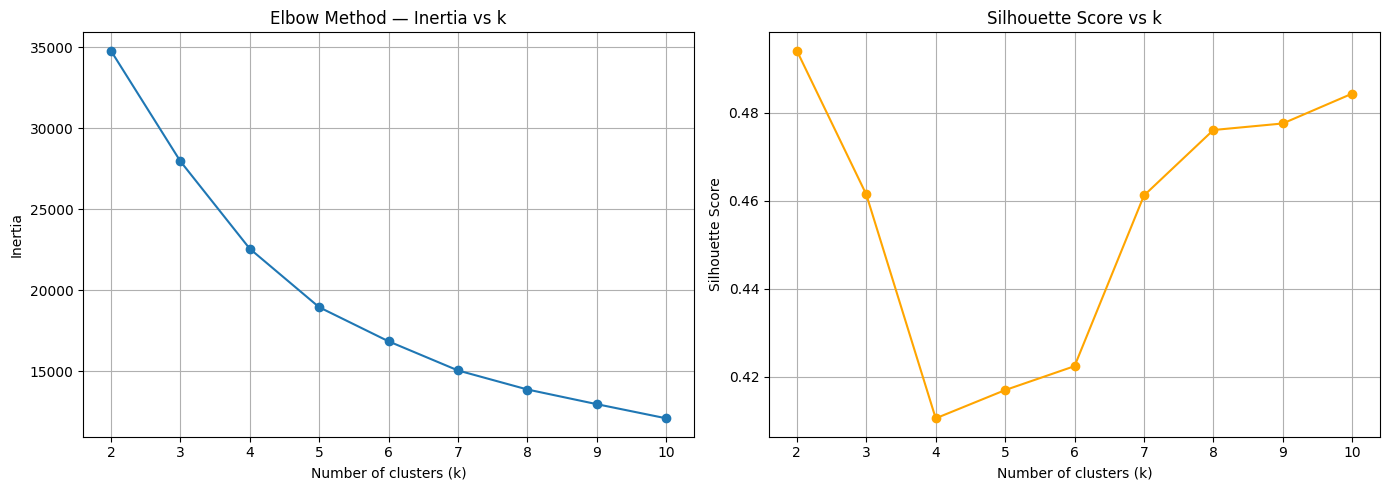


Best k based on silhouette score: 2
K-Means cluster distribution:
  Cluster 0: 10892 points
  Cluster 1: 9108 points

HIERARCHICAL CLUSTERING (AGGLOMERATIVE)
Hierarchical Clustering (k=2) silhouette score: 0.4868
Hierarchical cluster distribution:
  Cluster 0: 10472 points
  Cluster 1: 9528 points


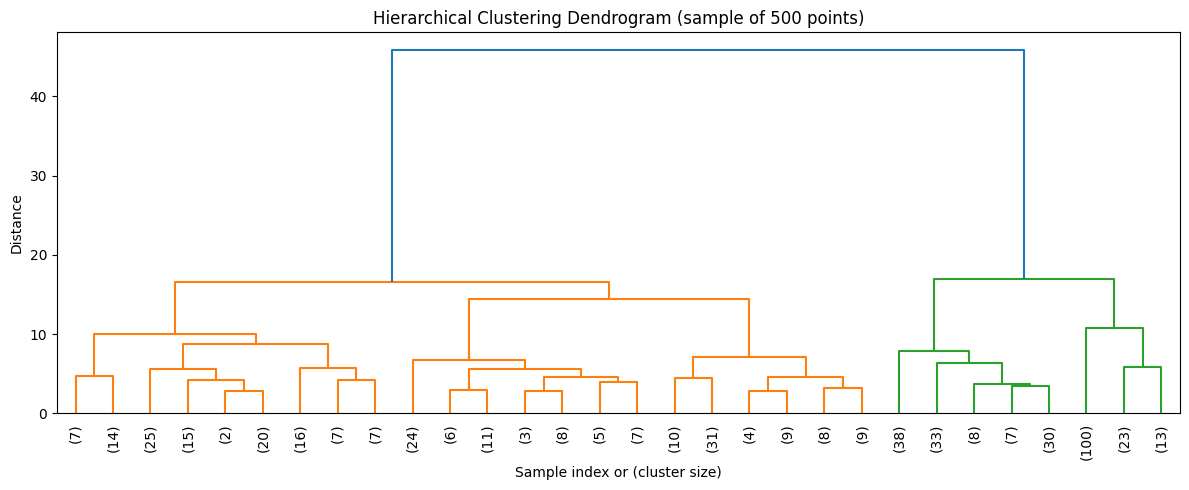


DBSCAN CLUSTERING


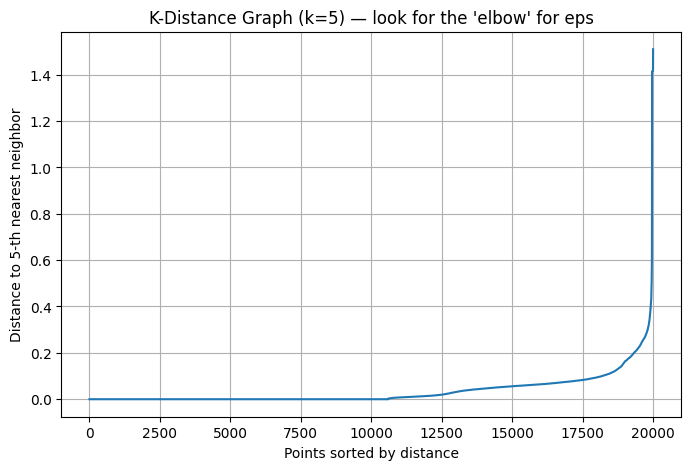

Estimated eps (90th percentile heuristic): 0.0940

DBSCAN found 226 clusters (excluding noise)
Noise points: 1447 (7.23% of data)
DBSCAN cluster distribution:
  Noise: 1447 points
  Cluster 0: 842 points
  Cluster 1: 1009 points
  Cluster 2: 4468 points
  Cluster 3: 5465 points
  Cluster 4: 420 points
  Cluster 5: 1441 points
  Cluster 6: 1231 points
  Cluster 7: 8 points
  Cluster 8: 13 points
  Cluster 9: 9 points
  Cluster 10: 11 points
  Cluster 11: 16 points
  Cluster 12: 6 points
  Cluster 13: 267 points
  Cluster 14: 11 points
  Cluster 15: 9 points
  Cluster 16: 70 points
  Cluster 17: 15 points
  Cluster 18: 598 points
  Cluster 19: 7 points
  Cluster 20: 5 points
  Cluster 21: 27 points
  Cluster 22: 27 points
  Cluster 23: 6 points
  Cluster 24: 10 points
  Cluster 25: 13 points
  Cluster 26: 11 points
  Cluster 27: 12 points
  Cluster 28: 5 points
  Cluster 29: 17 points
  Cluster 30: 88 points
  Cluster 31: 50 points
  Cluster 32: 162 points
  Cluster 33: 9 points
  Cluste

In [6]:
# ============================================================
# STEP 3: Clustering (K-Means, Hierarchical, DBSCAN)
# Unsupervised — trained ONLY on X_processed (no labels used)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# Optional but recommended for large datasets — UNSW-NB15 can have
# millions of rows, and Hierarchical/DBSCAN scale poorly on full data.
# If X_processed is very large, take a stratified-free random sample
# purely for clustering feasibility (still unsupervised — no labels used).
MAX_SAMPLES_FOR_CLUSTERING = 20000

if X_processed.shape[0] > MAX_SAMPLES_FOR_CLUSTERING:
    rng = np.random.default_rng(42)
    sample_idx = rng.choice(X_processed.shape[0], size=MAX_SAMPLES_FOR_CLUSTERING, replace=False)
    X_cluster = X_processed[sample_idx]
    print(f"Sampled {MAX_SAMPLES_FOR_CLUSTERING} rows out of {X_processed.shape[0]} for clustering.")
else:
    X_cluster = X_processed
    sample_idx = np.arange(X_processed.shape[0])
    print(f"Using full dataset for clustering: {X_cluster.shape[0]} rows.")

print(f"Clustering input shape: {X_cluster.shape}\n")


# ============================================================
# 3.1 K-MEANS CLUSTERING
# ============================================================

print("=" * 60)
print("K-MEANS CLUSTERING")
print("=" * 60)

# ------------------------------------------------------------
# Elbow method: inertia vs number of clusters
# ------------------------------------------------------------
k_range = range(2, 11)
inertias = []
silhouette_scores_kmeans = []

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_cluster)
    inertias.append(kmeans_temp.inertia_)
    score = silhouette_score(X_cluster, labels_temp, sample_size=5000, random_state=42)
    silhouette_scores_kmeans.append(score)
    print(f"k={k}: inertia={kmeans_temp.inertia_:.2f}, silhouette={score:.4f}")

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method — Inertia vs k")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].grid(True)

axes[1].plot(list(k_range), silhouette_scores_kmeans, marker="o", color="orange")
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Fit final K-Means with chosen k
# (Pick the k with the best silhouette score automatically;
#  override manually if you have domain reasoning to prefer another k)
# ------------------------------------------------------------
best_k = list(k_range)[int(np.argmax(silhouette_scores_kmeans))]
print(f"\nBest k based on silhouette score: {best_k}")

kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_model.fit_predict(X_cluster)

print(f"K-Means cluster distribution:")
unique, counts = np.unique(kmeans_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} points")


# ============================================================
# 3.2 HIERARCHICAL (AGGLOMERATIVE) CLUSTERING
# ============================================================

print("\n" + "=" * 60)
print("HIERARCHICAL CLUSTERING (AGGLOMERATIVE)")
print("=" * 60)

# Note: Agglomerative clustering has no direct "inertia", so we
# reuse the same k found via K-Means/silhouette analysis for a
# fair comparison, then verify with silhouette score.
hierarchical_model = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
hierarchical_labels = hierarchical_model.fit_predict(X_cluster)

hier_silhouette = silhouette_score(X_cluster, hierarchical_labels, sample_size=5000, random_state=42)
print(f"Hierarchical Clustering (k={best_k}) silhouette score: {hier_silhouette:.4f}")

print("Hierarchical cluster distribution:")
unique, counts = np.unique(hierarchical_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} points")

# ------------------------------------------------------------
# Optional dendrogram (on a smaller sub-sample for readability)
# ------------------------------------------------------------
from scipy.cluster.hierarchy import dendrogram, linkage

DENDRO_SAMPLE = 500
if X_cluster.shape[0] > DENDRO_SAMPLE:
    dendro_idx = np.random.default_rng(42).choice(X_cluster.shape[0], size=DENDRO_SAMPLE, replace=False)
    X_dendro = X_cluster[dendro_idx]
else:
    X_dendro = X_cluster

linkage_matrix = linkage(X_dendro, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(linkage_matrix, truncate_mode="lastp", p=30, leaf_rotation=90)
plt.title(f"Hierarchical Clustering Dendrogram (sample of {DENDRO_SAMPLE} points)")
plt.xlabel("Sample index or (cluster size)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


# ============================================================
# 3.3 DBSCAN CLUSTERING
# ============================================================

print("\n" + "=" * 60)
print("DBSCAN CLUSTERING")
print("=" * 60)

# ------------------------------------------------------------
# Estimate a reasonable eps using the k-distance graph
# (rule of thumb: k = min_samples)
# ------------------------------------------------------------
min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_cluster)
distances, indices = neighbors_fit.kneighbors(X_cluster)

# Sort distances to the k-th nearest neighbor
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.title(f"K-Distance Graph (k={min_samples}) — look for the 'elbow' for eps")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}-th nearest neighbor")
plt.grid(True)
plt.show()

# A simple heuristic pick: eps at the 90th percentile of k-distances.
# Inspect the plot above and adjust this manually if needed.
eps_estimate = np.percentile(k_distances, 90)
print(f"Estimated eps (90th percentile heuristic): {eps_estimate:.4f}")

dbscan_model = DBSCAN(eps=eps_estimate, min_samples=min_samples)
dbscan_labels = dbscan_model.fit_predict(X_cluster)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = np.sum(dbscan_labels == -1)

print(f"\nDBSCAN found {n_clusters_dbscan} clusters (excluding noise)")
print(f"Noise points: {n_noise} ({n_noise / len(dbscan_labels) * 100:.2f}% of data)")

print("DBSCAN cluster distribution:")
unique, counts = np.unique(dbscan_labels, return_counts=True)
for u, c in zip(unique, counts):
    label_name = "Noise" if u == -1 else f"Cluster {u}"
    print(f"  {label_name}: {c} points")

if n_clusters_dbscan > 1:
    # Silhouette score only makes sense excluding noise points
    mask = dbscan_labels != -1
    dbscan_silhouette = silhouette_score(X_cluster[mask], dbscan_labels[mask], sample_size=5000, random_state=42)
    print(f"\nDBSCAN silhouette score (excluding noise): {dbscan_silhouette:.4f}")
else:
    print("\nDBSCAN silhouette score not computed — fewer than 2 clusters found.")


# ============================================================
# 3.4 SUMMARY COMPARISON
# ============================================================

print("\n" + "=" * 60)
print("CLUSTERING SUMMARY COMPARISON")
print("=" * 60)

summary = {
    "K-Means": {
        "n_clusters": best_k,
        "silhouette": max(silhouette_scores_kmeans)
    },
    "Hierarchical": {
        "n_clusters": best_k,
        "silhouette": hier_silhouette
    },
    "DBSCAN": {
        "n_clusters": n_clusters_dbscan,
        "silhouette": dbscan_silhouette if n_clusters_dbscan > 1 else None
    }
}

for algo, metrics in summary.items():
    sil = f"{metrics['silhouette']:.4f}" if metrics["silhouette"] is not None else "N/A"
    print(f"{algo:15s} | clusters: {metrics['n_clusters']:3d} | silhouette: {sil}")

Aligned label subset shape: (20000, 2)
  attack_cat  label
0     Normal      0
1   Exploits      1
2        DoS      1
3     Normal      0
4     Normal      0

Combined results preview:
  attack_cat  label  kmeans_cluster  hierarchical_cluster  dbscan_cluster
0     Normal      0               0                     0               0
1   Exploits      1               1                     1              -1
2        DoS      1               1                     1              22
3     Normal      0               1                     1               1
4     Normal      0               0                     0               0

K-Means: kmeans_cluster vs label

Counts:
label              0     1
kmeans_cluster            
0               2394  8498
1               4792  4316

Row-normalized percentages (%):
label               0      1
kmeans_cluster              
0               21.98  78.02
1               52.61  47.39


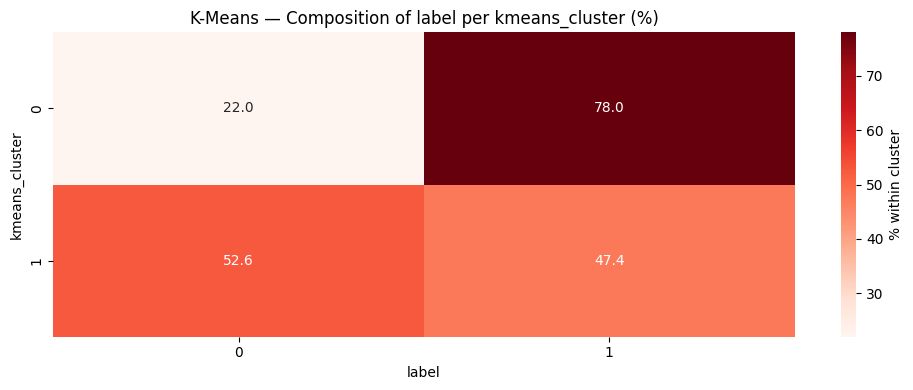

Hierarchical: hierarchical_cluster vs label

Counts:
label                    0     1
hierarchical_cluster            
0                     2050  8422
1                     5136  4392

Row-normalized percentages (%):
label                     0      1
hierarchical_cluster              
0                     19.58  80.42
1                     53.90  46.10


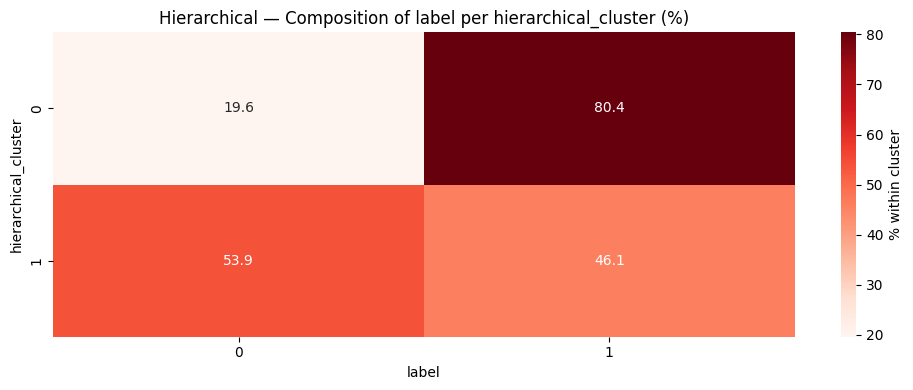

DBSCAN: dbscan_cluster vs label

Counts:
label              0     1
dbscan_cluster            
-1               601   846
 0               832    10
 1               384   625
 2                 6  4462
 3              3327  2138
...              ...   ...
 221               0     5
 222               8     0
 223               0     5
 224               1     5
 225               1     3

[227 rows x 2 columns]

Row-normalized percentages (%):
label                0       1
dbscan_cluster                
-1               41.53   58.47
 0               98.81    1.19
 1               38.06   61.94
 2                0.13   99.87
 3               60.88   39.12
...                ...     ...
 221              0.00  100.00
 222            100.00    0.00
 223              0.00  100.00
 224             16.67   83.33
 225             25.00   75.00

[227 rows x 2 columns]


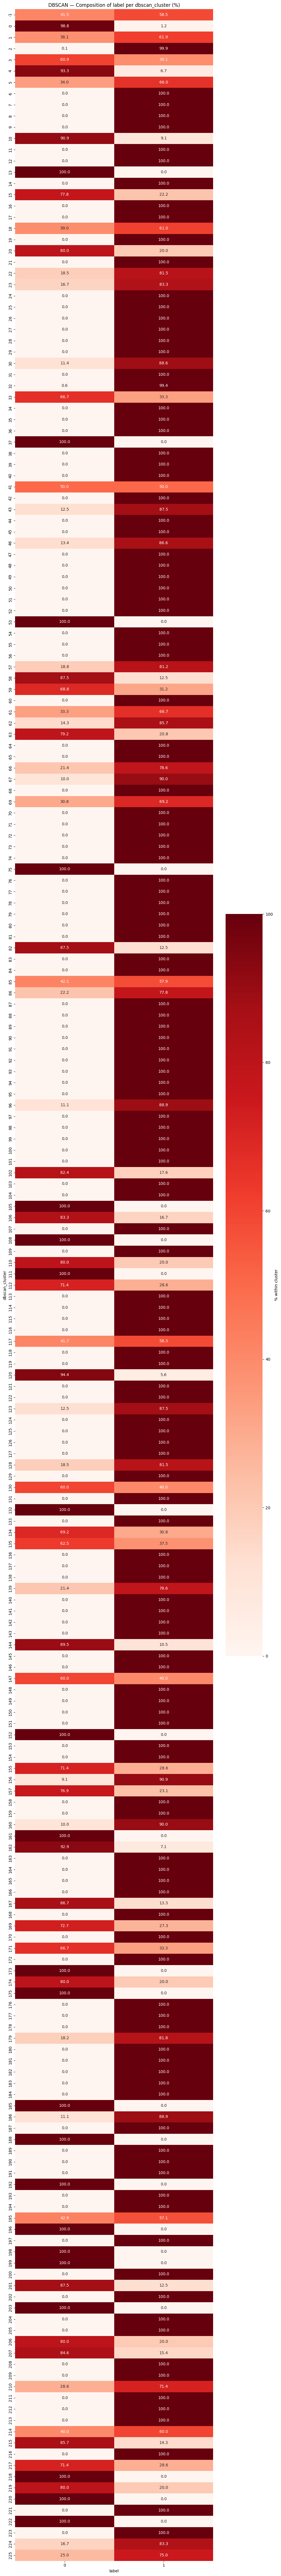

K-Means: kmeans_cluster vs attack_cat

Counts:
attack_cat      Analysis  Backdoor   DoS  Exploits  Fuzzers  Generic  Normal  \
kmeans_cluster                                                                 
0                    158       176  1019      1314      712     4487    2394   
1                     48        13   258      2096     1201       67    4792   

attack_cat      Reconnaissance  Shellcode  Worms  
kmeans_cluster                                    
0                          567         62      3  
1                          558         64     11  

Row-normalized percentages (%):
attack_cat      Analysis  Backdoor   DoS  Exploits  Fuzzers  Generic  Normal  \
kmeans_cluster                                                                 
0                   1.45      1.62  9.36     12.06     6.54    41.20   21.98   
1                   0.53      0.14  2.83     23.01    13.19     0.74   52.61   

attack_cat      Reconnaissance  Shellcode  Worms  
kmeans_cluster         

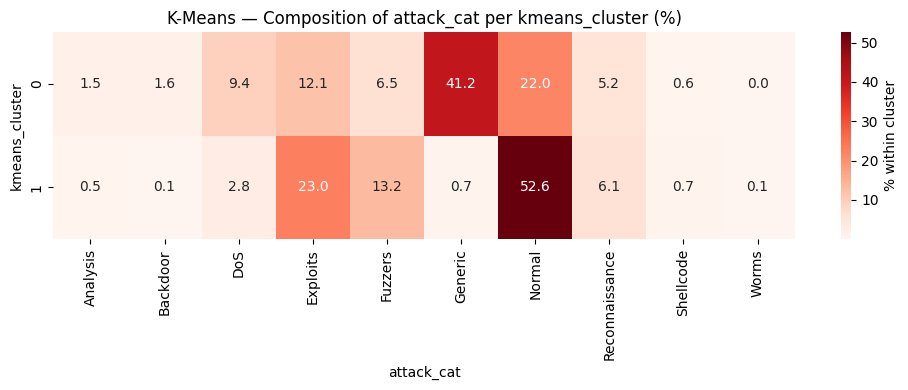

Hierarchical: hierarchical_cluster vs attack_cat

Counts:
attack_cat            Analysis  Backdoor   DoS  Exploits  Fuzzers  Generic  \
hierarchical_cluster                                                         
0                          157       175  1012      1281      692     4486   
1                           49        14   265      2129     1221       68   

attack_cat            Normal  Reconnaissance  Shellcode  Worms  
hierarchical_cluster                                            
0                       2050             555         61      3  
1                       5136             570         65     11  

Row-normalized percentages (%):
attack_cat            Analysis  Backdoor   DoS  Exploits  Fuzzers  Generic  \
hierarchical_cluster                                                         
0                         1.50      1.67  9.66     12.23     6.61    42.84   
1                         0.51      0.15  2.78     22.34    12.81     0.71   

attack_cat            N

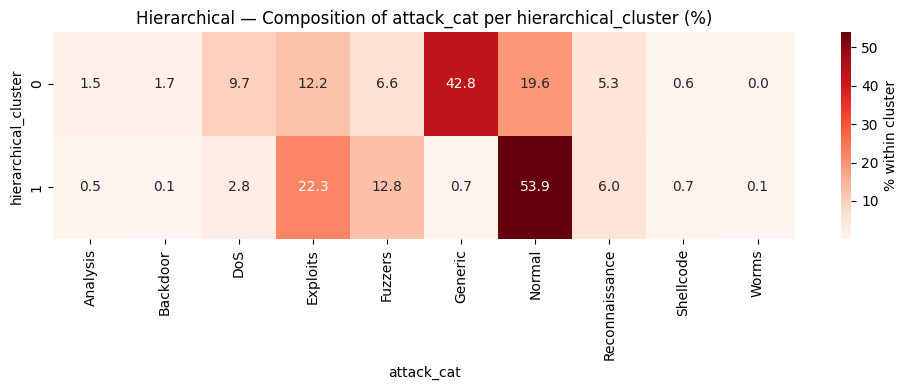

DBSCAN: dbscan_cluster vs attack_cat

Counts:
attack_cat      Analysis  Backdoor  DoS  Exploits  Fuzzers  Generic  Normal  \
dbscan_cluster                                                                
-1                     7         3   49       702       60       12     601   
 0                     0         0    1         9        0        0     832   
 1                    18         0   54       431       32       15     384   
 2                     0         0    5         7       16     4431       6   
 3                     4        11   91       472     1090       20    3327   
...                  ...       ...  ...       ...      ...      ...     ...   
 221                   0         0    0         5        0        0       0   
 222                   0         0    0         0        0        0       8   
 223                   0         0    0         5        0        0       0   
 224                   1         0    0         3        1        0       1   
 225  

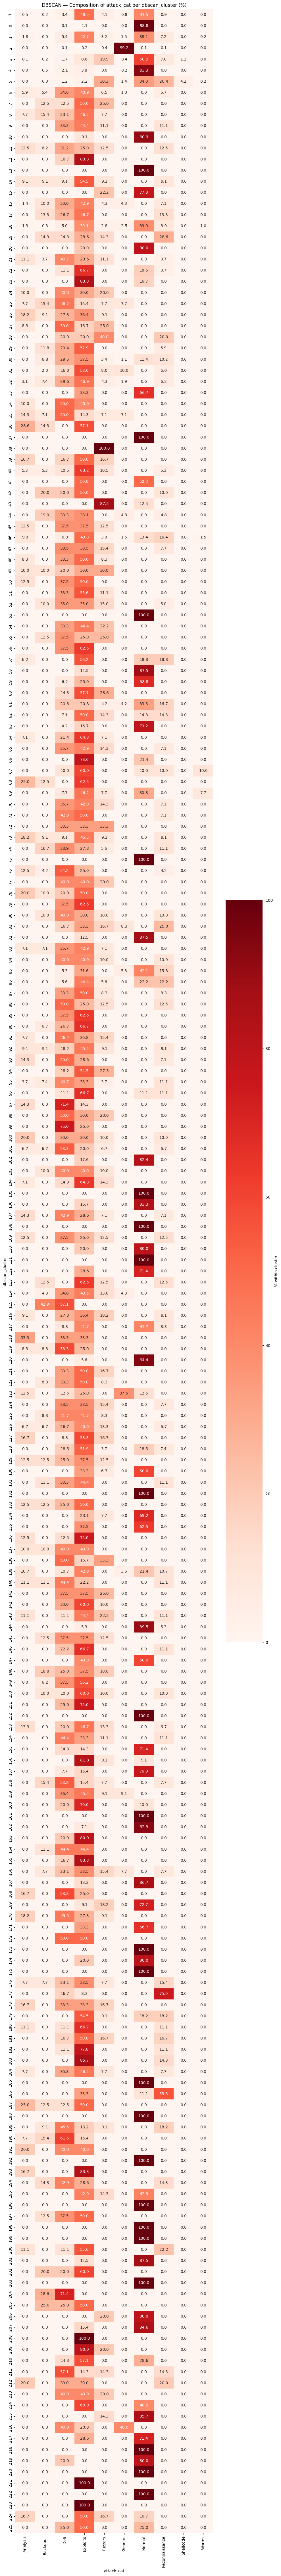


ANOMALY-DOMINANT CLUSTER SUMMARY

kmeans_cluster — % attack traffic per cluster:
kmeans_cluster
0    78.02
1    47.39
Name: label, dtype: float64

hierarchical_cluster — % attack traffic per cluster:
hierarchical_cluster
0    80.42
1    46.10
Name: label, dtype: float64

dbscan_cluster — % attack traffic per cluster:
dbscan_cluster
7      100.0
8      100.0
9      100.0
31     100.0
26     100.0
       ...  
198      0.0
203      0.0
218      0.0
220      0.0
222      0.0
Name: label, Length: 227, dtype: float64

DBSCAN noise points: 1447 total
% of noise points that are actual attacks: 58.47%
(Compare to overall attack rate in sample: 64.07%)


In [7]:
# ============================================================
# STEP 4: Cluster Interpretation (Labels Used ONLY Here)
# Labels are used post-hoc to profile clusters — not for training
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Align the original labels to the sampled rows used for clustering
#    (recall: sample_idx was created in Step 3 when we subsampled
#    X_processed for clustering feasibility)
# ------------------------------------------------------------
if df_labels is not None:
    labels_sampled = df_labels.iloc[sample_idx].reset_index(drop=True)
else:
    raise ValueError("No label columns were found in Step 2 (df_labels is None). "
                      "Cannot perform label-based interpretation.")

print(f"Aligned label subset shape: {labels_sampled.shape}")
print(labels_sampled.head())
print()

# ------------------------------------------------------------
# 2. Build a combined results dataframe: cluster assignments + labels
# ------------------------------------------------------------
results_df = labels_sampled.copy()
results_df["kmeans_cluster"] = kmeans_labels
results_df["hierarchical_cluster"] = hierarchical_labels
results_df["dbscan_cluster"] = dbscan_labels

print("Combined results preview:")
print(results_df.head())
print()

# ------------------------------------------------------------
# 3. Helper function: cross-tab of cluster vs label, with
#    normalized (%) view to show attack composition per cluster
# ------------------------------------------------------------
def profile_clusters(df, cluster_col, label_col, title):
    print("=" * 70)
    print(f"{title}: {cluster_col} vs {label_col}")
    print("=" * 70)

    ct_counts = pd.crosstab(df[cluster_col], df[label_col])
    ct_percent = pd.crosstab(df[cluster_col], df[label_col], normalize="index") * 100

    print("\nCounts:")
    print(ct_counts)
    print("\nRow-normalized percentages (%):")
    print(ct_percent.round(2))

    # Heatmap of percentages
    plt.figure(figsize=(10, max(4, 0.4 * ct_percent.shape[0])))
    sns.heatmap(ct_percent, annot=True, fmt=".1f", cmap="Reds", cbar_kws={"label": "% within cluster"})
    plt.title(f"{title} — Composition of {label_col} per {cluster_col} (%)")
    plt.ylabel(cluster_col)
    plt.xlabel(label_col)
    plt.tight_layout()
    plt.show()

    return ct_counts, ct_percent


# ------------------------------------------------------------
# 4. Profile against 'label' (binary: normal=0 vs attack=1)
#    Column name may vary — adjust if your dataset differs
# ------------------------------------------------------------
binary_label_col = next((c for c in results_df.columns if c.lower() == "label"), None)
attack_cat_col = next((c for c in results_df.columns if c.lower() == "attack_cat"), None)

if binary_label_col:
    profile_clusters(results_df, "kmeans_cluster", binary_label_col, "K-Means")
    profile_clusters(results_df, "hierarchical_cluster", binary_label_col, "Hierarchical")
    profile_clusters(results_df, "dbscan_cluster", binary_label_col, "DBSCAN")

# ------------------------------------------------------------
# 5. Profile against 'attack_cat' (multi-class attack category)
#    Reveals whether clusters correspond to specific attack types
# ------------------------------------------------------------
if attack_cat_col:
    profile_clusters(results_df, "kmeans_cluster", attack_cat_col, "K-Means")
    profile_clusters(results_df, "hierarchical_cluster", attack_cat_col, "Hierarchical")
    profile_clusters(results_df, "dbscan_cluster", attack_cat_col, "DBSCAN")

# ------------------------------------------------------------
# 6. Identify "anomalous" clusters: those dominated by attack traffic
#    (useful for framing this as a threat-detection outcome)
# ------------------------------------------------------------
if binary_label_col:
    print("\n" + "=" * 70)
    print("ANOMALY-DOMINANT CLUSTER SUMMARY")
    print("=" * 70)

    for cluster_col in ["kmeans_cluster", "hierarchical_cluster", "dbscan_cluster"]:
        attack_rate = results_df.groupby(cluster_col)[binary_label_col].mean() * 100
        print(f"\n{cluster_col} — % attack traffic per cluster:")
        print(attack_rate.round(2).sort_values(ascending=False))

# ------------------------------------------------------------
# 7. DBSCAN-specific: noise points as potential anomalies
#    Noise (-1) points are often the most interesting from a
#    threat-detection standpoint — they don't fit any normal pattern
# ------------------------------------------------------------
if binary_label_col:
    noise_mask = results_df["dbscan_cluster"] == -1
    if noise_mask.sum() > 0:
        noise_attack_rate = results_df.loc[noise_mask, binary_label_col].mean() * 100
        print(f"\nDBSCAN noise points: {noise_mask.sum()} total")
        print(f"% of noise points that are actual attacks: {noise_attack_rate:.2f}%")
        overall_attack_rate = results_df[binary_label_col].mean() * 100
        print(f"(Compare to overall attack rate in sample: {overall_attack_rate:.2f}%)")

PCA explained variance ratio: [0.61977519 0.10591568]
Total variance captured by 2 components: 72.57%

Sampled 5000 points out of 20000 for t-SNE.
t-SNE projection complete.


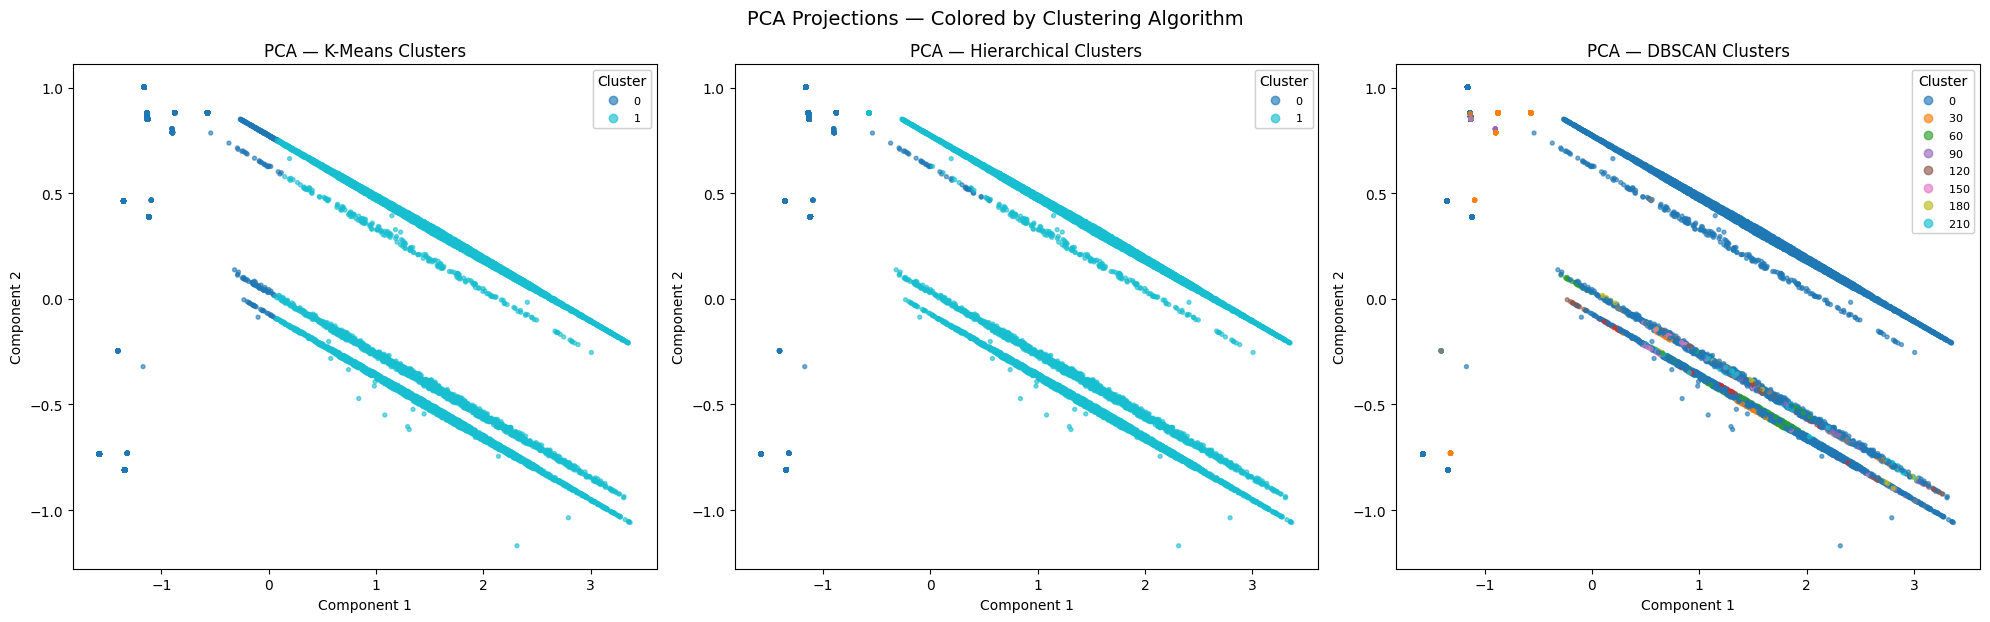

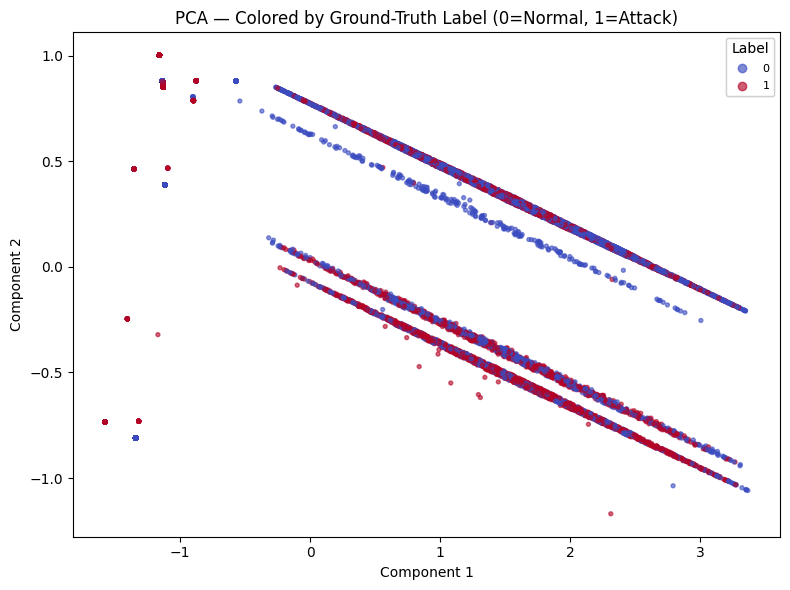

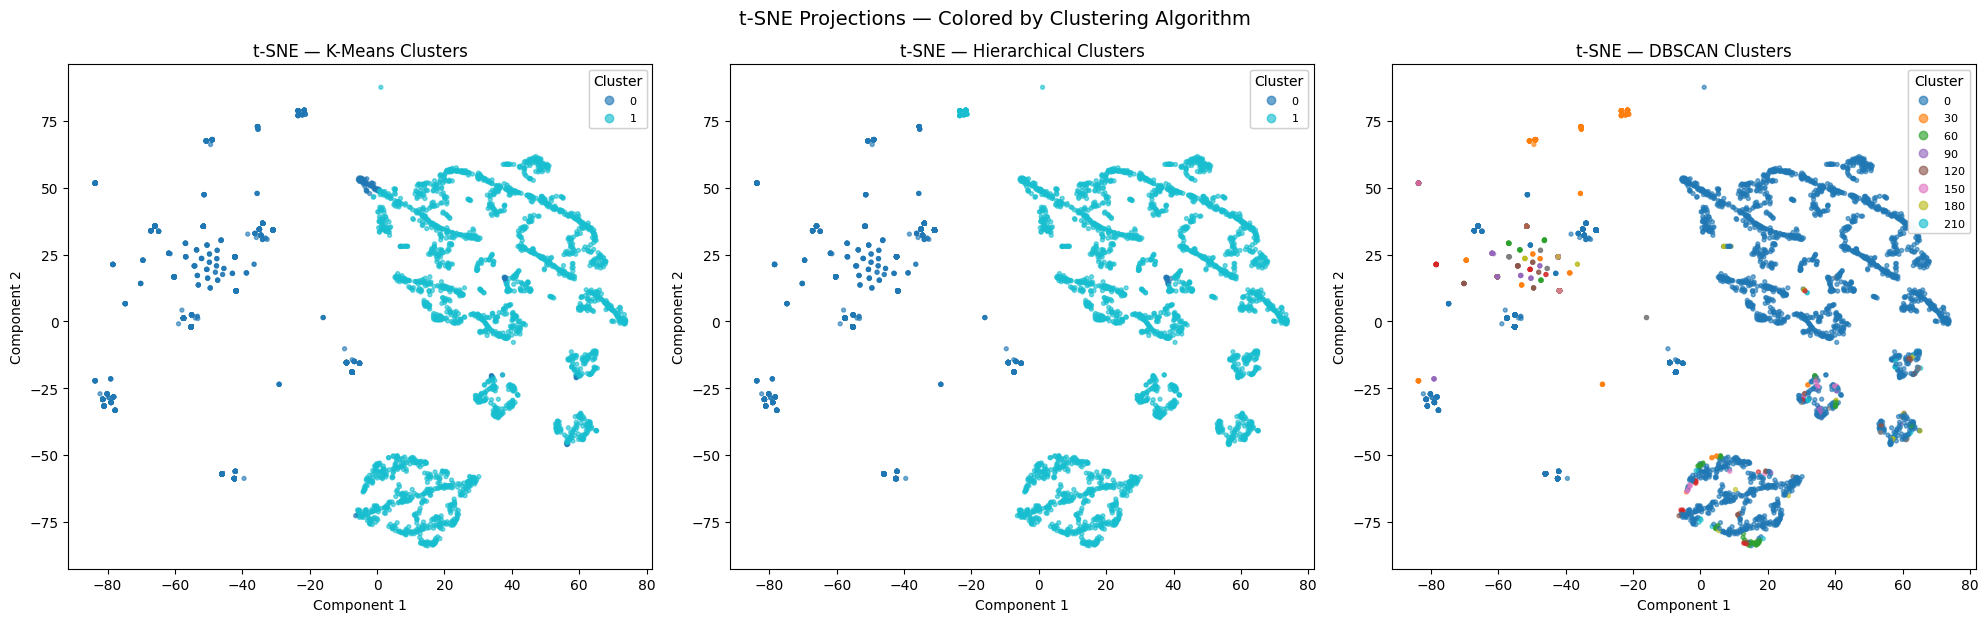

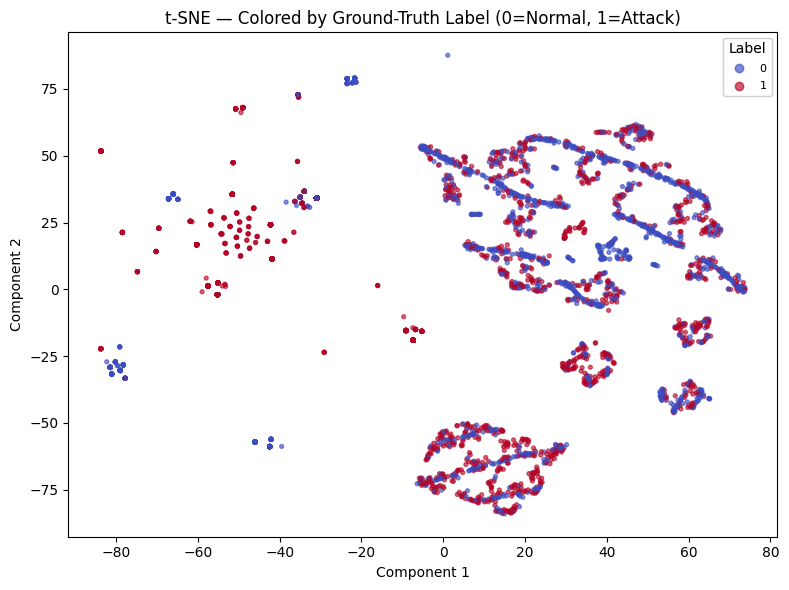

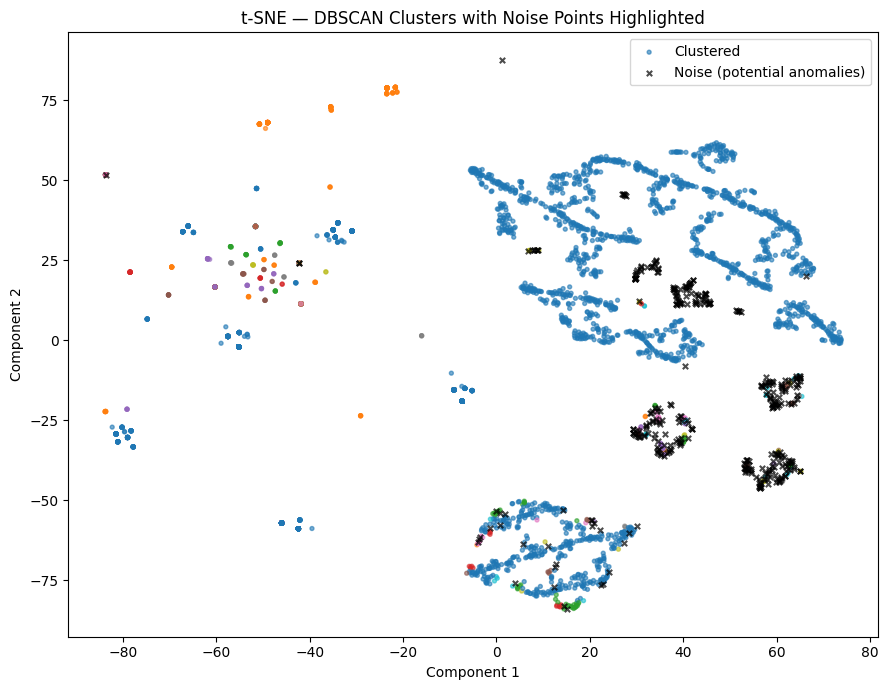

In [8]:
# ============================================================
# STEP 5: Dimensionality Reduction & Visualization
# PCA + t-SNE projections of clustering results (labels used
# only for coloring plots, never for the projection/fitting)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ------------------------------------------------------------
# 1. PCA projection to 2D (fast, linear, good baseline)
# ------------------------------------------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

explained_var = pca.explained_variance_ratio_
print(f"PCA explained variance ratio: {explained_var}")
print(f"Total variance captured by 2 components: {explained_var.sum() * 100:.2f}%")

# ------------------------------------------------------------
# 2. t-SNE projection to 2D (slower, non-linear, often reveals
#    cluster structure PCA misses — capped on sample size)
# ------------------------------------------------------------
TSNE_MAX_SAMPLES = 5000

if X_cluster.shape[0] > TSNE_MAX_SAMPLES:
    tsne_idx = np.random.default_rng(42).choice(X_cluster.shape[0], size=TSNE_MAX_SAMPLES, replace=False)
    X_tsne_input = X_cluster[tsne_idx]
    print(f"\nSampled {TSNE_MAX_SAMPLES} points out of {X_cluster.shape[0]} for t-SNE.")
else:
    tsne_idx = np.arange(X_cluster.shape[0])
    X_tsne_input = X_cluster
    print(f"\nUsing all {X_cluster.shape[0]} points for t-SNE.")

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init="pca", learning_rate="auto")
X_tsne = tsne.fit_transform(X_tsne_input)

print("t-SNE projection complete.")


# ============================================================
# 3. Helper function to plot a 2D projection colored by a
#    given label/cluster array
# ============================================================
def plot_2d_projection(X_2d, color_values, title, ax, cmap="tab10", legend_title="Cluster"):
    scatter = ax.scatter(
        X_2d[:, 0], X_2d[:, 1],
        c=color_values, cmap=cmap, s=8, alpha=0.6
    )
    ax.set_title(title)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    legend1 = ax.legend(*scatter.legend_elements(), title=legend_title, loc="best", fontsize=8)
    ax.add_artist(legend1)


# ============================================================
# 4. PCA plots — colored by each clustering algorithm's labels
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

plot_2d_projection(X_pca, kmeans_labels, "PCA — K-Means Clusters", axes[0])
plot_2d_projection(X_pca, hierarchical_labels, "PCA — Hierarchical Clusters", axes[1])
plot_2d_projection(X_pca, dbscan_labels, "PCA — DBSCAN Clusters", axes[2])

plt.tight_layout()
plt.suptitle("PCA Projections — Colored by Clustering Algorithm", y=1.03, fontsize=14)
plt.show()

# ------------------------------------------------------------
# 5. PCA plot colored by ground-truth attack label
#    (only NOW do we bring in the label — purely for visual
#    comparison against unsupervised cluster shapes above)
# ------------------------------------------------------------
if binary_label_col:
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_2d_projection(
        X_pca, results_df[binary_label_col].values,
        "PCA — Colored by Ground-Truth Label (0=Normal, 1=Attack)",
        ax, cmap="coolwarm", legend_title="Label"
    )
    plt.tight_layout()
    plt.show()


# ============================================================
# 6. t-SNE plots — colored by each clustering algorithm's labels
#    (note: t-SNE used a sub-sample, so we must slice cluster
#    label arrays with the same tsne_idx for alignment)
# ============================================================
kmeans_labels_tsne = kmeans_labels[tsne_idx]
hierarchical_labels_tsne = hierarchical_labels[tsne_idx]
dbscan_labels_tsne = dbscan_labels[tsne_idx]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

plot_2d_projection(X_tsne, kmeans_labels_tsne, "t-SNE — K-Means Clusters", axes[0])
plot_2d_projection(X_tsne, hierarchical_labels_tsne, "t-SNE — Hierarchical Clusters", axes[1])
plot_2d_projection(X_tsne, dbscan_labels_tsne, "t-SNE — DBSCAN Clusters", axes[2])

plt.tight_layout()
plt.suptitle("t-SNE Projections — Colored by Clustering Algorithm", y=1.03, fontsize=14)
plt.show()

# ------------------------------------------------------------
# 7. t-SNE plot colored by ground-truth attack label
# ------------------------------------------------------------
if binary_label_col:
    label_tsne = results_df[binary_label_col].values[tsne_idx]

    fig, ax = plt.subplots(figsize=(8, 6))
    plot_2d_projection(
        X_tsne, label_tsne,
        "t-SNE — Colored by Ground-Truth Label (0=Normal, 1=Attack)",
        ax, cmap="coolwarm", legend_title="Label"
    )
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 8. Side-by-side: DBSCAN clusters vs noise highlighted separately
#    (noise points are often the most interesting for threat detection)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 7))

is_noise = dbscan_labels_tsne == -1
ax.scatter(X_tsne[~is_noise, 0], X_tsne[~is_noise, 1],
           c=dbscan_labels_tsne[~is_noise], cmap="tab10", s=8, alpha=0.6, label="Clustered")
ax.scatter(X_tsne[is_noise, 0], X_tsne[is_noise, 1],
           c="black", marker="x", s=15, alpha=0.7, label="Noise (potential anomalies)")

ax.set_title("t-SNE — DBSCAN Clusters with Noise Points Highlighted")
ax.set_xlabel("Component 1")
ax.set_ylabel("Component 2")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

EXTERNAL VALIDATION — vs BINARY LABEL (Normal=0, Attack=1)
                 ARI     NMI  Homogeneity  Completeness  V-Measure  \
Algorithm                                                            
K-Means       0.1076  0.0762       0.0784        0.0742     0.0762   
Hierarchical  0.1264  0.0972       0.1001        0.0944     0.0972   
DBSCAN        0.0923  0.1716       0.4467        0.1062     0.1716   

              Fowlkes-Mallows  
Algorithm                      
K-Means                0.5730  
Hierarchical           0.5807  
DBSCAN                 0.3668  

EXTERNAL VALIDATION — vs ATTACK CATEGORY (multi-class)
                 ARI     NMI  Homogeneity  Completeness  V-Measure  \
Algorithm                                                            
K-Means       0.1295  0.1529       0.1075        0.2647     0.1529   
Hierarchical  0.1519  0.1672       0.1177        0.2885     0.1672   
DBSCAN        0.3672  0.3738       0.4895        0.3024     0.3738   

              Fowlkes-M

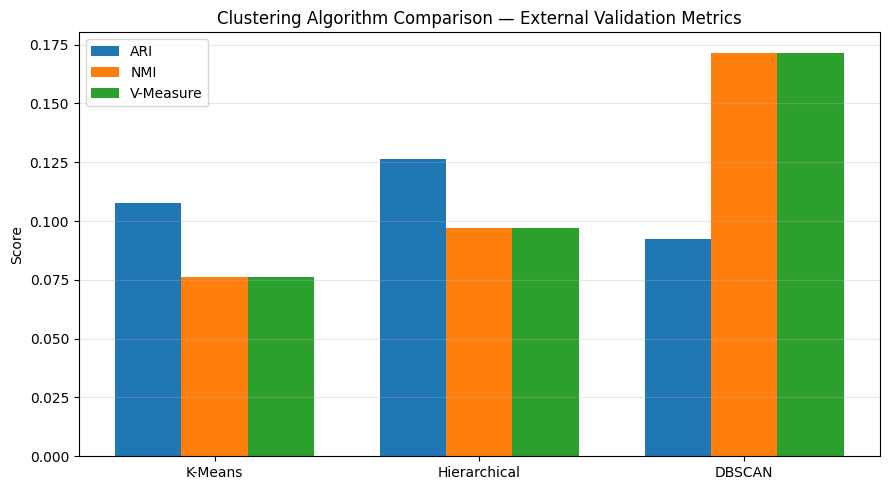

In [9]:
# ============================================================
# STEP 6: Formal Evaluation Metrics (Reporting Only)
# Comparing unsupervised clustering results against ground-truth
# labels using external validation metrics. Used ONLY for
# evaluation/reporting — not for tuning or training.
# ============================================================

import pandas as pd
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
    fowlkes_mallows_score,
    silhouette_score
)

# ------------------------------------------------------------
# 1. Define ground-truth arrays (binary label + attack_cat if available)
# ------------------------------------------------------------
if binary_label_col is None:
    raise ValueError("Binary 'label' column not found — cannot compute external validation metrics.")

y_true_binary = results_df[binary_label_col].values
y_true_multi = results_df[attack_cat_col].values if attack_cat_col else None

cluster_results = {
    "K-Means": kmeans_labels,
    "Hierarchical": hierarchical_labels,
    "DBSCAN": dbscan_labels
}

# ------------------------------------------------------------
# 2. External validation metrics — how well do clusters align
#    with ground-truth labels (WITHOUT having used them to fit)?
#
#    - ARI: Adjusted Rand Index — similarity between two labelings,
#      corrected for chance. Range: -1 to 1 (1 = perfect match).
#    - NMI: Normalized Mutual Information — how much information
#      is shared between cluster assignment and true label.
#    - Homogeneity: each cluster contains only members of a single class.
#    - Completeness: all members of a class are assigned to the same cluster.
#    - V-measure: harmonic mean of homogeneity and completeness.
#    - Fowlkes-Mallows: geometric mean of pairwise precision/recall.
# ------------------------------------------------------------
def compute_external_metrics(y_true, y_pred, algo_name):
    return {
        "Algorithm": algo_name,
        "ARI": adjusted_rand_score(y_true, y_pred),
        "NMI": normalized_mutual_info_score(y_true, y_pred),
        "Homogeneity": homogeneity_score(y_true, y_pred),
        "Completeness": completeness_score(y_true, y_pred),
        "V-Measure": v_measure_score(y_true, y_pred),
        "Fowlkes-Mallows": fowlkes_mallows_score(y_true, y_pred)
    }

# ------------------------------------------------------------
# 3. Compute metrics against binary label (Normal vs Attack)
# ------------------------------------------------------------
print("=" * 70)
print("EXTERNAL VALIDATION — vs BINARY LABEL (Normal=0, Attack=1)")
print("=" * 70)

binary_metrics = []
for algo_name, labels in cluster_results.items():
    binary_metrics.append(compute_external_metrics(y_true_binary, labels, algo_name))

binary_metrics_df = pd.DataFrame(binary_metrics).set_index("Algorithm")
print(binary_metrics_df.round(4))

# ------------------------------------------------------------
# 4. Compute metrics against multi-class attack_cat (if available)
# ------------------------------------------------------------
if y_true_multi is not None:
    print("\n" + "=" * 70)
    print("EXTERNAL VALIDATION — vs ATTACK CATEGORY (multi-class)")
    print("=" * 70)

    multi_metrics = []
    for algo_name, labels in cluster_results.items():
        multi_metrics.append(compute_external_metrics(y_true_multi, labels, algo_name))

    multi_metrics_df = pd.DataFrame(multi_metrics).set_index("Algorithm")
    print(multi_metrics_df.round(4))

# ------------------------------------------------------------
# 5. Internal validation metrics (no labels needed) — recap
#    for a complete side-by-side comparison table
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("INTERNAL VALIDATION — Silhouette Score (no labels used)")
print("=" * 70)

internal_metrics = {
    "K-Means": silhouette_score(X_cluster, kmeans_labels, sample_size=5000, random_state=42),
    "Hierarchical": silhouette_score(X_cluster, hierarchical_labels, sample_size=5000, random_state=42),
}

if n_clusters_dbscan > 1:
    mask = dbscan_labels != -1
    internal_metrics["DBSCAN"] = silhouette_score(X_cluster[mask], dbscan_labels[mask], sample_size=5000, random_state=42)
else:
    internal_metrics["DBSCAN"] = None

internal_metrics_df = pd.DataFrame.from_dict(internal_metrics, orient="index", columns=["Silhouette Score"])
print(internal_metrics_df.round(4))

# ------------------------------------------------------------
# 6. Combined final scorecard
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("FINAL COMBINED SCORECARD (Binary Label + Internal Metrics)")
print("=" * 70)

final_scorecard = binary_metrics_df.copy()
final_scorecard["Silhouette Score"] = internal_metrics_df["Silhouette Score"]
print(final_scorecard.round(4))

# ------------------------------------------------------------
# 7. Bar chart visualization of ARI/NMI across algorithms
# ------------------------------------------------------------
import matplotlib.pyplot as plt

metrics_to_plot = ["ARI", "NMI", "V-Measure"]
fig, ax = plt.subplots(figsize=(9, 5))

x = range(len(cluster_results))
width = 0.25

for i, metric in enumerate(metrics_to_plot):
    values = binary_metrics_df[metric].values
    ax.bar([p + i * width for p in x], values, width=width, label=metric)

ax.set_xticks([p + width for p in x])
ax.set_xticklabels(binary_metrics_df.index)
ax.set_ylabel("Score")
ax.set_title("Clustering Algorithm Comparison — External Validation Metrics")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# ENHANCEMENT 1: CLUSTER BEHAVIORAL PROFILING (K-Means)
# ============================================================

# Align ORIGINAL (unscaled) feature values to the same sample used for clustering,
# so profiles are interpretable in real units (seconds, bytes, packets) rather
# than scaled/encoded values.
df_features_sampled = df_features.iloc[sample_idx].reset_index(drop=True)
df_features_sampled["kmeans_cluster"] = kmeans_labels

overall_numeric_means = df_features_sampled[numerical_cols].mean()

cluster_profiles = {}

print("=" * 70)
print("CLUSTER BEHAVIORAL PROFILING — K-MEANS")
print("=" * 70)

for cluster_id in sorted(df_features_sampled["kmeans_cluster"].unique()):
    cluster_data = df_features_sampled[df_features_sampled["kmeans_cluster"] == cluster_id]
    cluster_size = len(cluster_data)

    print(f"\n--- Cluster {cluster_id} (size: {cluster_size}, "
          f"{cluster_size / len(df_features_sampled) * 100:.1f}% of sample) ---")

    # Compare this cluster's numerical averages against the overall dataset average
    cluster_means = cluster_data[numerical_cols].mean()
    pct_diff = ((cluster_means - overall_numeric_means) / overall_numeric_means.replace(0, np.nan)) * 100
    pct_diff = pct_diff.replace([np.inf, -np.inf], np.nan).dropna().sort_values(key=abs, ascending=False)

    print("\nTop distinguishing numerical features (vs. overall average):")
    top_features = pct_diff.head(6)
    for feat, diff in top_features.items():
        direction = "higher" if diff > 0 else "lower"
        print(f"  {feat:20s}: {abs(diff):7.1f}% {direction} than overall "
              f"(cluster mean={cluster_means[feat]:.2f}, overall mean={overall_numeric_means[feat]:.2f})")

    # Most common categorical values in this cluster
    print("\nMost common categorical values:")
    for col in categorical_cols:
        mode_val = cluster_data[col].mode()
        mode_val = mode_val.iloc[0] if not mode_val.empty else "N/A"
        mode_pct = (cluster_data[col] == mode_val).mean() * 100
        print(f"  {col:10s}: '{mode_val}' ({mode_pct:.1f}% of cluster)")

    # Cautious, rule-based interpretation — descriptive only, never definitive
    interpretation_notes = []
    high_feats = [f for f, d in top_features.items() if d > 50]
    low_feats = [f for f, d in top_features.items() if d < -50]

    if any(f in ["sbytes", "dbytes", "sload", "dload"] for f in high_feats):
        interpretation_notes.append("high data-transfer network activity")
    if any(f in ["spkts", "dpkts", "rate"] for f in high_feats) and "dur" in low_feats:
        interpretation_notes.append("high-frequency, short-duration connection behavior")
    if any(f in ["sjit", "djit", "tcprtt"] for f in high_feats):
        interpretation_notes.append("irregular timing/jitter pattern consistent with unusual network activity")
    if not interpretation_notes:
        interpretation_notes.append("no strongly distinguishing behavioral pattern identified")

    print("\nCautious interpretation:")
    print(f"  Pattern potentially consistent with: {'; '.join(interpretation_notes)}.")
    print("  Note: descriptive observation only — does NOT confirm an attack; "
          "requires further investigation.")

    cluster_profiles[cluster_id] = {
        "size": cluster_size,
        "top_features": top_features,
        "interpretation": interpretation_notes
    }

CLUSTER BEHAVIORAL PROFILING — K-MEANS

--- Cluster 0 (size: 10892, 54.5% of sample) ---

Top distinguishing numerical features (vs. overall average):
  stcpb               :    99.4% lower than overall (cluster mean=6476695.99, overall mean=1019350717.64)
  dtcpb               :    99.3% lower than overall (cluster mean=6641244.92, overall mean=999408321.78)

Most common categorical values:
  proto     : 'udp' (66.3% of cluster)
  service   : '-' (50.3% of cluster)
  state     : 'INT' (82.6% of cluster)

Cautious interpretation:
  Pattern potentially consistent with: no strongly distinguishing behavioral pattern identified.
  Note: descriptive observation only — does NOT confirm an attack; requires further investigation.

--- Cluster 1 (size: 9108, 45.5% of sample) ---

Top distinguishing numerical features (vs. overall average):
  stcpb               :   118.8% higher than overall (cluster mean=2230618157.68, overall mean=1019350717.64)
  dtcpb               :   118.8% higher than ov

POST-HOC CLUSTER EXPLAINABILITY (Random Forest, informational only)

Classifier accuracy in reproducing K-Means cluster assignments: 99.83%
(High accuracy is expected here — it confirms the clusters are genuinely
 separable in feature space; it does NOT mean the model predicts attacks.)

Top 10 features separating the discovered clusters:
num__stcpb           0.2594
num__dtcpb           0.2040
cat__state_FIN       0.1388
cat__proto_tcp       0.1205
cat__state_INT       0.0961
cat__proto_udp       0.0759
cat__service_dns     0.0462
cat__service_http    0.0203
cat__proto_unas      0.0085
cat__state_CON       0.0051
dtype: float64


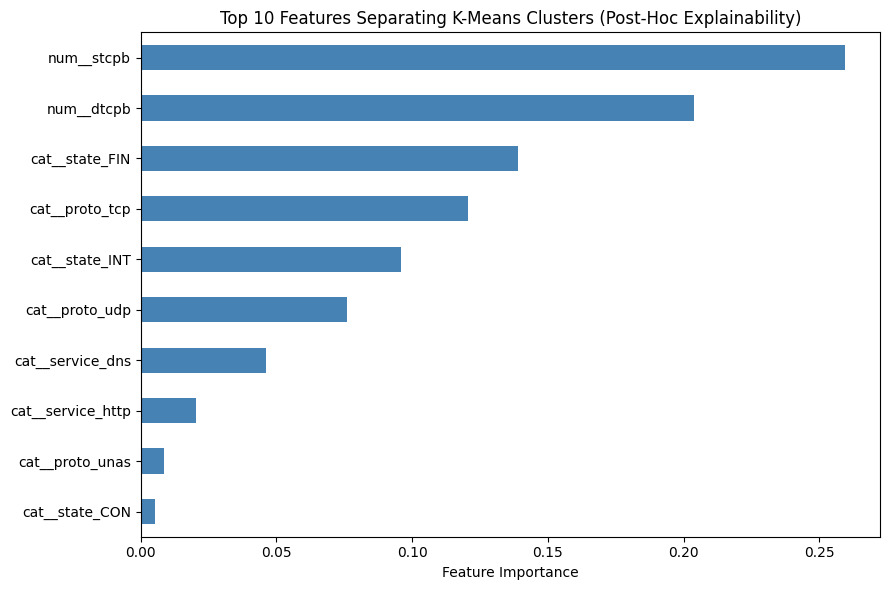


These features are the strongest drivers of the behavioral groups discovered by unsupervised clustering — they explain WHY the clusters differ, not whether any given record is an attack.


In [11]:
# ============================================================
# ENHANCEMENT 2: POST-HOC CLUSTER EXPLAINABILITY
# ============================================================
# NOTE: This classifier is NOT part of the clustering model.
# It is trained AFTER clustering, using the already-discovered K-Means
# cluster labels purely as a post-hoc explainability tool to understand
# which features separate the clusters. It plays no role in forming
# the clusters themselves and is not an attack classifier.

from sklearn.ensemble import RandomForestClassifier

explainer_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# X_cluster = the same processed feature matrix K-Means was fit on (Step 3)
# kmeans_labels = the cluster assignments K-Means already produced
explainer_model.fit(X_cluster, kmeans_labels)

importances = pd.Series(explainer_model.feature_importances_, index=feature_names)
top_10_features = importances.sort_values(ascending=False).head(10)

print("=" * 70)
print("POST-HOC CLUSTER EXPLAINABILITY (Random Forest, informational only)")
print("=" * 70)
print(f"\nClassifier accuracy in reproducing K-Means cluster assignments: "
      f"{explainer_model.score(X_cluster, kmeans_labels) * 100:.2f}%")
print("(High accuracy is expected here — it confirms the clusters are genuinely\n"
      " separable in feature space; it does NOT mean the model predicts attacks.)")

print("\nTop 10 features separating the discovered clusters:")
print(top_10_features.round(4))

plt.figure(figsize=(9, 6))
top_10_features.sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 10 Features Separating K-Means Clusters (Post-Hoc Explainability)")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

print("\nThese features are the strongest drivers of the behavioral groups "
      "discovered by unsupervised clustering — they explain WHY the clusters "
      "differ, not whether any given record is an attack.")

EXPERIMENTAL THREAT RISK SCORING (clustering-based, not validated)

Risk level distribution:
risk_level
Low Risk         10787
Medium Risk       7521
High Risk          323
Critical Risk     1369
Name: count, dtype: int64

Total records scored: 20000


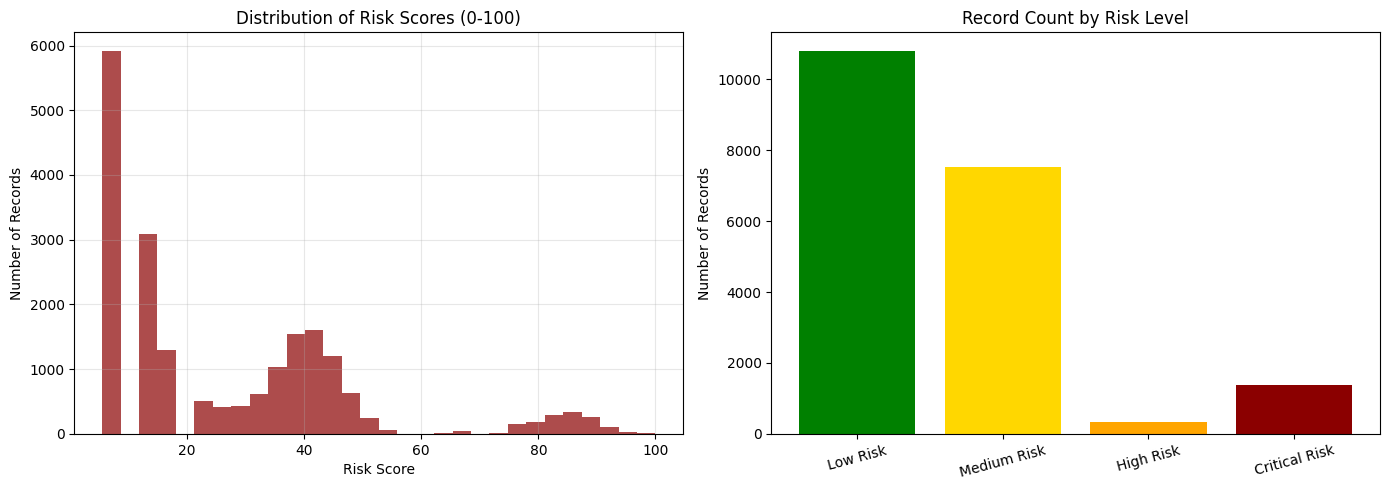


Sample High/Critical Risk records (for review — labels shown for context only):


,risk_score,risk_level,kmeans_cluster,dbscan_cluster,attack_cat,label
7067,100.000000,Critical Risk,1,-1,Exploits,1
7017,98.615366,Critical Risk,1,-1,Normal,0
2469,98.396324,Critical Risk,1,-1,Normal,0
121,97.890327,Critical Risk,1,-1,Normal,0
3784,97.237246,Critical Risk,1,-1,Normal,0
10559,97.170493,Critical Risk,1,-1,Exploits,1
16990,97.166256,Critical Risk,1,-1,Normal,0
19707,96.984119,Critical Risk,1,-1,Normal,0
16439,96.850282,Critical Risk,1,-1,Normal,0
17016,96.552767,Critical Risk,1,-1,Normal,0


In [12]:
# ============================================================
# ENHANCEMENT 3: ENSEMBLE THREAT RISK SCORING (Experimental)
# ============================================================
# IMPORTANT: This is an EXPERIMENTAL, clustering-based threat prioritization
# score for exploratory analysis only. It is NOT a validated real-world
# cybersecurity risk score and should not drive operational decisions
# without expert review. Attack labels play no role in computing it.

from sklearn.preprocessing import MinMaxScaler

# --- Component 1: DBSCAN anomaly status (noise = higher risk) ---
dbscan_risk_component = (dbscan_labels == -1).astype(float)

# --- Component 2: Distance from assigned K-Means centroid ---
centroids = kmeans_model.cluster_centers_
distances_to_centroid = np.array([
    np.linalg.norm(X_cluster[i] - centroids[kmeans_labels[i]])
    for i in range(X_cluster.shape[0])
])
distance_risk_component = MinMaxScaler().fit_transform(
    distances_to_centroid.reshape(-1, 1)
).flatten()

# --- Component 3: Cluster rarity (smaller K-Means cluster = higher risk) ---
cluster_size_lookup = pd.Series(kmeans_labels).value_counts()
cluster_sizes = pd.Series(kmeans_labels).map(cluster_size_lookup)
rarity_risk_component = MinMaxScaler().fit_transform(
    (1 / cluster_sizes.values).reshape(-1, 1)
).flatten()

# --- Combine into a single 0-100 risk score ---
# Transparent, fixed weighting (documented for reproducibility):
#   40% DBSCAN anomaly status, 35% centroid distance, 25% cluster rarity
risk_score = (
    0.40 * dbscan_risk_component +
    0.35 * distance_risk_component +
    0.25 * rarity_risk_component
) * 100

results_df["risk_score"] = risk_score

def classify_risk(score):
    if score < 25:
        return "Low Risk"
    elif score < 50:
        return "Medium Risk"
    elif score < 75:
        return "High Risk"
    else:
        return "Critical Risk"

results_df["risk_level"] = results_df["risk_score"].apply(classify_risk)

print("=" * 70)
print("EXPERIMENTAL THREAT RISK SCORING (clustering-based, not validated)")
print("=" * 70)

risk_order = ["Low Risk", "Medium Risk", "High Risk", "Critical Risk"]
risk_distribution = results_df["risk_level"].value_counts().reindex(risk_order).fillna(0).astype(int)

print("\nRisk level distribution:")
print(risk_distribution)
print(f"\nTotal records scored: {len(results_df)}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(results_df["risk_score"], bins=30, color="darkred", alpha=0.7)
axes[0].set_title("Distribution of Risk Scores (0-100)")
axes[0].set_xlabel("Risk Score")
axes[0].set_ylabel("Number of Records")
axes[0].grid(alpha=0.3)

colors = {"Low Risk": "green", "Medium Risk": "gold", "High Risk": "orange", "Critical Risk": "darkred"}
axes[1].bar(risk_distribution.index, risk_distribution.values,
            color=[colors[level] for level in risk_distribution.index])
axes[1].set_title("Record Count by Risk Level")
axes[1].set_ylabel("Number of Records")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# Sample of high-risk / critical-risk records.
# attack_cat/label are shown here ONLY for human review of the results —
# they had no role in computing the risk score above.
print("\nSample High/Critical Risk records (for review — labels shown for context only):")
high_risk_sample = results_df[
    results_df["risk_level"].isin(["High Risk", "Critical Risk"])
].sort_values("risk_score", ascending=False).head(10)

display(high_risk_sample[["risk_score", "risk_level", "kmeans_cluster",
                           "dbscan_cluster", "attack_cat", "label"]])

In [14]:
# ============================================================
# ENHANCEMENT 4: AUTOMATED THREAT INTELLIGENCE REPORT
# ============================================================

print("=" * 60)
print("NETWORK THREAT INTELLIGENCE REPORT")
print("=" * 60)

print(f"\nTotal Traffic Analysed (full dataset): {df.shape[0]:,} records")
print(f"Records Used for Clustering (subsample): {X_cluster.shape[0]:,} records")

print(f"\nK-Means Clusters: {best_k}")
print(f"Hierarchical Clusters: {best_k}")
print(f"DBSCAN Clusters (excluding noise): {n_clusters_dbscan}")

dbscan_noise_count = int((dbscan_labels == -1).sum())
dbscan_noise_pct = dbscan_noise_count / len(dbscan_labels) * 100
print(f"\nDBSCAN Anomalies (noise points): {dbscan_noise_count:,} "
      f"({dbscan_noise_pct:.2f}% of clustered sample)")

print("\nBest Clustering Evaluation Metrics (vs. ground-truth label, from Step 6):")
print(binary_metrics_df.round(4))

print("\nThreat Risk Distribution (experimental scoring):")
print(risk_distribution)

high_critical_count = int(results_df["risk_level"].isin(["High Risk", "Critical Risk"]).sum())
print(f"\nHigh Risk + Critical Risk Records: {high_critical_count:,} "
      f"({high_critical_count / len(results_df) * 100:.2f}% of clustered sample)")

print("\nKey Behavioral Features Separating Clusters (post-hoc explainability):")
print(top_10_features.round(4))

print("\n" + "-" * 60)
print("Key Finding:")
print("-" * 60)
print(
    "Unsupervised clustering of network traffic behavior surfaced distinct\n"
    "behavioral groups without using attack labels during training.\n"
    f"DBSCAN flagged {dbscan_noise_pct:.1f}% of traffic as density-based\n"
    f"anomalies, and the experimental risk score identified {high_critical_count:,}\n"
    "records as High/Critical risk based purely on clustering geometry\n"
    "(anomaly status, distance from cluster centroid, cluster rarity).\n"
    "These findings are exploratory and require expert review before any\n"
    "operational security action is taken."
)
print("=" * 60)

NETWORK THREAT INTELLIGENCE REPORT

Total Traffic Analysed (full dataset): 257,673 records
Records Used for Clustering (subsample): 20,000 records

K-Means Clusters: 2
Hierarchical Clusters: 2
DBSCAN Clusters (excluding noise): 226

DBSCAN Anomalies (noise points): 1,447 (7.23% of clustered sample)

Best Clustering Evaluation Metrics (vs. ground-truth label, from Step 6):
                 ARI     NMI  Homogeneity  Completeness  V-Measure  \
Algorithm                                                            
K-Means       0.1076  0.0762       0.0784        0.0742     0.0762   
Hierarchical  0.1264  0.0972       0.1001        0.0944     0.0972   
DBSCAN        0.0923  0.1716       0.4467        0.1062     0.1716   

              Fowlkes-Mallows  
Algorithm                      
K-Means                0.5730  
Hierarchical           0.5807  
DBSCAN                 0.3668  

Threat Risk Distribution (experimental scoring):
risk_level
Low Risk         10787
Medium Risk       7521
High Ri

STEP 11: POST-HOC THREAT SCORE VALIDATION

Validating 'risk_level' against ground-truth 'label'.
Ground-truth labels are used HERE ONLY to check whether the risk score
(computed without labels) tends to prioritize actual attack traffic.

Threat Risk Level vs Ground-Truth Label — Summary:
               Total Records  Normal Count  Attack Count  Attack %  Normal %
Risk Level                                                                  
Low Risk               10787          2332          8455     78.38     21.62
Medium Risk             7521          4114          3407     45.30     54.70
High Risk                323           182           141     43.65     56.35
Critical Risk           1369           558           811     59.24     40.76


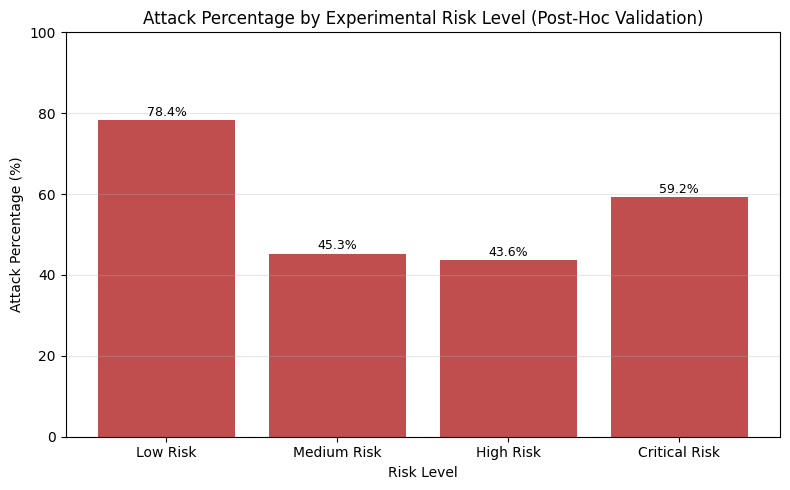


----------------------------------------------------------------------
TREND ANALYSIS
----------------------------------------------------------------------
Attack % by risk level (in order): {'Low Risk': 78.38, 'Medium Risk': 45.3, 'High Risk': 43.65, 'Critical Risk': 59.24}
Step-by-step changes in Attack %: [-33.08, -1.65, 15.59]

Conclusion: Post-hoc validation does not show a consistent increase in attack percentage across risk levels. The experimental risk score does not perfectly align with the ground-truth labels in this run. This is expected for a purely unsupervised, label-free scoring method and highlights a direction for further tuning rather than a validated detection result.

Note: this is exploratory post-hoc validation of an experimental score, not a supervised evaluation, and the risk score itself was not modified based on these results.


In [15]:
# ============================================================
# STEP 11: POST-HOC THREAT SCORE VALIDATION
# Labels used ONLY to validate the already-computed experimental risk
# score — NOT to modify, retrain, or tune it. This is exploratory
# post-hoc validation, not supervised evaluation.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Adjust these two constants if your Enhancement 3 code used
#     different column names for the risk score / risk level ---
RISK_LEVEL_COL = "risk_level"
RISK_SCORE_COL = "risk_score"

risk_order = ["Low Risk", "Medium Risk", "High Risk", "Critical Risk"]

print("=" * 70)
print("STEP 11: POST-HOC THREAT SCORE VALIDATION")
print("=" * 70)
print(f"\nValidating '{RISK_LEVEL_COL}' against ground-truth '{binary_label_col}'.")
print("Ground-truth labels are used HERE ONLY to check whether the risk score")
print("(computed without labels) tends to prioritize actual attack traffic.\n")

# ------------------------------------------------------------
# 1. Per-risk-level summary: totals, normal count, attack count, %s
# ------------------------------------------------------------
validation_rows = []

for level in risk_order:
    level_data = results_df[results_df[RISK_LEVEL_COL] == level]
    total = len(level_data)

    if total == 0:
        # Handle a risk level with no records safely
        validation_rows.append({
            "Risk Level": level,
            "Total Records": 0,
            "Normal Count": 0,
            "Attack Count": 0,
            "Attack %": np.nan,
            "Normal %": np.nan
        })
        continue

    normal_count = int((level_data[binary_label_col] == 0).sum())
    attack_count = int((level_data[binary_label_col] == 1).sum())
    attack_pct = attack_count / total * 100
    normal_pct = normal_count / total * 100

    validation_rows.append({
        "Risk Level": level,
        "Total Records": total,
        "Normal Count": normal_count,
        "Attack Count": attack_count,
        "Attack %": round(attack_pct, 2),
        "Normal %": round(normal_pct, 2)
    })

validation_summary_df = pd.DataFrame(validation_rows).set_index("Risk Level")

print("Threat Risk Level vs Ground-Truth Label — Summary:")
print(validation_summary_df)

# ------------------------------------------------------------
# 2. Visualization: Risk Level vs Attack Percentage
# ------------------------------------------------------------
plot_df = validation_summary_df.dropna(subset=["Attack %"])

plt.figure(figsize=(8, 5))
bars = plt.bar(plot_df.index, plot_df["Attack %"], color="firebrick", alpha=0.8)
plt.title("Attack Percentage by Experimental Risk Level (Post-Hoc Validation)")
plt.xlabel("Risk Level")
plt.ylabel("Attack Percentage (%)")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

# Label each bar with its value
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1,
              f"{height:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Automated trend analysis (Low -> Medium -> High -> Critical)
#    Does NOT force a positive conclusion — reports what's actually there.
# ------------------------------------------------------------
attack_pct_sequence = plot_df["Attack %"].tolist()
levels_present = plot_df.index.tolist()

print("\n" + "-" * 70)
print("TREND ANALYSIS")
print("-" * 70)
print(f"Attack % by risk level (in order): {dict(zip(levels_present, attack_pct_sequence))}")

if len(attack_pct_sequence) < 2:
    print("\nNot enough risk levels with data to assess a trend.")
else:
    # Check whether the sequence is non-decreasing step-by-step
    step_diffs = np.diff(attack_pct_sequence)
    is_monotonic_increasing = np.all(step_diffs >= 0)
    is_generally_increasing = (attack_pct_sequence[-1] > attack_pct_sequence[0]) and \
                               (np.sum(step_diffs > 0) >= np.sum(step_diffs < 0))

    print(f"Step-by-step changes in Attack %: {np.round(step_diffs, 2).tolist()}")

    if is_monotonic_increasing:
        print(
            "\nConclusion: Post-hoc validation indicates that higher experimental "
            "risk levels are associated with a greater proportion of attack-labelled "
            "traffic, with attack percentage increasing consistently at every step "
            "from Low Risk through Critical Risk."
        )
    elif is_generally_increasing:
        print(
            "\nConclusion: Post-hoc validation indicates that higher experimental "
            "risk levels are generally associated with a greater proportion of "
            "attack-labelled traffic, though the increase is not perfectly "
            "monotonic across every risk level."
        )
    else:
        print(
            "\nConclusion: Post-hoc validation does not show a consistent increase "
            "in attack percentage across risk levels. The experimental risk score "
            "does not perfectly align with the ground-truth labels in this run. "
            "This is expected for a purely unsupervised, label-free scoring method "
            "and highlights a direction for further tuning rather than a validated "
            "detection result."
        )

print(
    "\nNote: this is exploratory post-hoc validation of an experimental score, "
    "not a supervised evaluation, and the risk score itself was not modified "
    "based on these results."
)

STEP 12: ATTACK CATEGORY ENRICHMENT ANALYSIS

Top overall attack categories (dataset-wide): ['Generic', 'Exploits', 'Fuzzers', 'DoS', 'Reconnaissance']

--- Low Risk (Total records: 10787) ---
                Count  Percentage
attack_cat                       
Generic          4486       41.59
Normal           2332       21.62
Exploits         1286       11.92
DoS              1014        9.40
Fuzzers           708        6.56
Reconnaissance    566        5.25
Other             395        3.66

Top 5 attack categories within Low Risk:
attack_cat
Generic     4486
Normal      2332
Exploits    1286
DoS         1014
Fuzzers      708
Name: count, dtype: int64

--- Medium Risk (Total records: 7521) ---
                Count  Percentage
attack_cat                       
Normal           4114       54.70
Exploits         1363       18.12
Fuzzers          1123       14.93
Reconnaissance    533        7.09
DoS               208        2.77
Other             127        1.69
Generic            53 

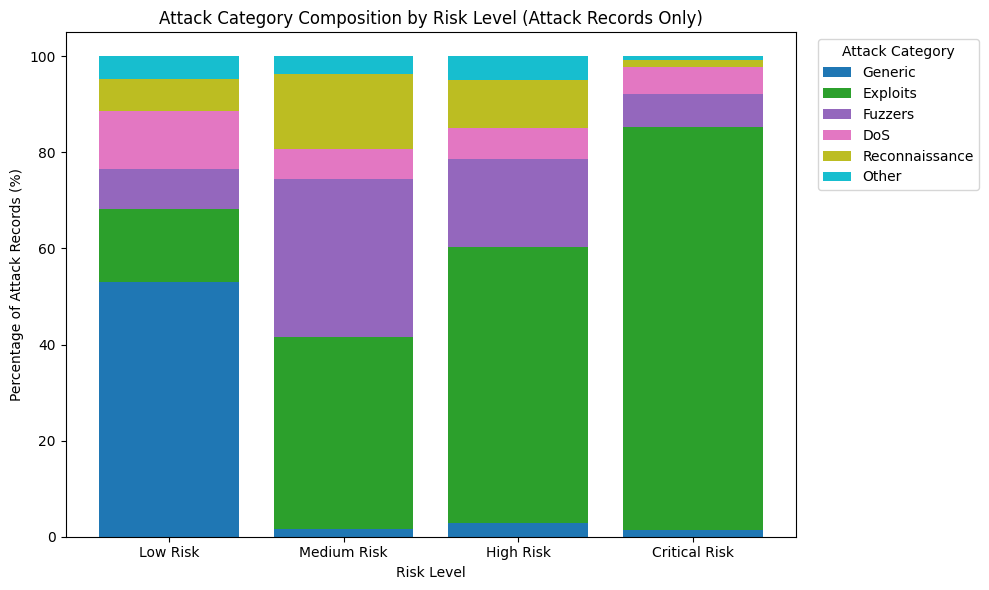


HIGH + CRITICAL RISK — ATTACK CATEGORY DEEP DIVE

Total High + Critical Risk records: 1692

Attack category distribution:
                Count  Percentage
attack_cat                       
Exploits          761       44.98
Normal            740       43.74
Fuzzers            82        4.85
DoS                55        3.25
Reconnaissance     26        1.54
Generic            15        0.89
Other              13        0.77

Top 5 attack categories in High + Critical Risk records:
attack_cat
Exploits          761
Normal            740
Fuzzers            82
DoS                55
Reconnaissance     26
Name: count, dtype: int64

----------------------------------------------------------------------
INTERPRETATION
----------------------------------------------------------------------
Post-hoc enrichment analysis shows that High and Critical risk traffic contains a higher representation of Exploits compared with the overall attack traffic distribution.

FINAL SUMMARY TABLE — POST-HOC THREA

In [16]:
# ============================================================
# STEP 12: ATTACK CATEGORY ENRICHMENT ANALYSIS
# attack_cat used ONLY for post-hoc interpretation — not used to
# modify clustering or the risk score.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("STEP 12: ATTACK CATEGORY ENRICHMENT ANALYSIS")
print("=" * 70)

if attack_cat_col is None:
    print("\n'attack_cat' column not available — skipping enrichment analysis.")
else:
    # ------------------------------------------------------------
    # 1. Determine top overall attack categories (for chart readability)
    #    "Normal" is excluded when ranking ATTACK categories specifically.
    # ------------------------------------------------------------
    attack_only_df = results_df[results_df[binary_label_col] == 1]
    top_overall_categories = (
        attack_only_df[attack_cat_col].value_counts().head(5).index.tolist()
    )
    print(f"\nTop overall attack categories (dataset-wide): {top_overall_categories}")

    def summarize_categories(df_subset, top_categories):
        """Return counts + percentages for a subset, grouping non-top attack
        categories as 'Other'. Normal traffic is kept as its own category."""
        total = len(df_subset)
        if total == 0:
            return pd.DataFrame(columns=["Count", "Percentage"])

        cats = df_subset[attack_cat_col].apply(
            lambda c: c if (c == "Normal" or c in top_categories) else "Other"
        )
        counts = cats.value_counts()
        pct = (counts / total * 100).round(2)
        return pd.DataFrame({"Count": counts, "Percentage": pct})

    # ------------------------------------------------------------
    # 2. Per-risk-level attack category distribution
    # ------------------------------------------------------------
    per_level_summaries = {}

    for level in risk_order:
        level_data = results_df[results_df[RISK_LEVEL_COL] == level]
        total = len(level_data)

        print(f"\n--- {level} (Total records: {total}) ---")

        if total == 0:
            print("No records at this risk level.")
            per_level_summaries[level] = pd.DataFrame(columns=["Count", "Percentage"])
            continue

        summary = summarize_categories(level_data, top_overall_categories)
        per_level_summaries[level] = summary
        print(summary)

        top5_this_level = level_data[attack_cat_col].value_counts().head(5)
        print(f"\nTop 5 attack categories within {level}:")
        print(top5_this_level)

    # ------------------------------------------------------------
    # 3. Visualization: attack-category distribution across risk levels
    #    (stacked bar, top categories + "Other", Normal excluded from view
    #    since we're focused on attack-category composition)
    # ------------------------------------------------------------
    chart_data = {}
    categories_for_chart = top_overall_categories + ["Other"]

    for level in risk_order:
        level_data = results_df[
            (results_df[RISK_LEVEL_COL] == level) & (results_df[binary_label_col] == 1)
        ]
        total_attacks = len(level_data)
        if total_attacks == 0:
            chart_data[level] = [0] * len(categories_for_chart)
            continue

        cats = level_data[attack_cat_col].apply(
            lambda c: c if c in top_overall_categories else "Other"
        )
        cat_pct = (cats.value_counts(normalize=True) * 100).reindex(
            categories_for_chart, fill_value=0
        )
        chart_data[level] = cat_pct.tolist()

    chart_df = pd.DataFrame(chart_data, index=categories_for_chart).T

    fig, ax = plt.subplots(figsize=(10, 6))
    bottom = np.zeros(len(chart_df))
    colors = plt.cm.tab10(np.linspace(0, 1, len(categories_for_chart)))

    for i, category in enumerate(categories_for_chart):
        ax.bar(chart_df.index, chart_df[category], bottom=bottom,
               label=category, color=colors[i])
        bottom += chart_df[category].values

    ax.set_title("Attack Category Composition by Risk Level (Attack Records Only)")
    ax.set_ylabel("Percentage of Attack Records (%)")
    ax.set_xlabel("Risk Level")
    ax.legend(title="Attack Category", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # 4. Separate deep-dive: High Risk + Critical Risk combined
    # ------------------------------------------------------------
    high_critical_df = results_df[
        results_df[RISK_LEVEL_COL].isin(["High Risk", "Critical Risk"])
    ]
    total_high_critical = len(high_critical_df)

    print("\n" + "=" * 70)
    print("HIGH + CRITICAL RISK — ATTACK CATEGORY DEEP DIVE")
    print("=" * 70)
    print(f"\nTotal High + Critical Risk records: {total_high_critical}")

    if total_high_critical == 0:
        print("No High/Critical Risk records to analyze.")
        high_critical_top5 = pd.Series(dtype=int)
    else:
        hc_distribution = summarize_categories(high_critical_df, top_overall_categories)
        print("\nAttack category distribution:")
        print(hc_distribution)

        high_critical_top5 = high_critical_df[attack_cat_col].value_counts().head(5)
        print("\nTop 5 attack categories in High + Critical Risk records:")
        print(high_critical_top5)

    # ------------------------------------------------------------
    # 5. Cautious automated interpretation — only stated if supported
    # ------------------------------------------------------------
    print("\n" + "-" * 70)
    print("INTERPRETATION")
    print("-" * 70)

    if total_high_critical > 0:
        hc_attack_only = high_critical_df[high_critical_df[binary_label_col] == 1]
        overall_attack_only = results_df[results_df[binary_label_col] == 1]

        if len(hc_attack_only) > 0 and len(overall_attack_only) > 0:
            hc_cat_pct = hc_attack_only[attack_cat_col].value_counts(normalize=True) * 100
            overall_cat_pct = overall_attack_only[attack_cat_col].value_counts(normalize=True) * 100

            # Categories over-represented in High+Critical vs overall attack traffic
            enriched_categories = []
            for cat in hc_cat_pct.index:
                overall_val = overall_cat_pct.get(cat, 0)
                if hc_cat_pct[cat] > overall_val + 5:  # simple, transparent threshold
                    enriched_categories.append(cat)

            if enriched_categories:
                print(
                    "Post-hoc enrichment analysis shows that High and Critical risk "
                    f"traffic contains a higher representation of {', '.join(enriched_categories)} "
                    "compared with the overall attack traffic distribution."
                )
            else:
                print(
                    "Post-hoc enrichment analysis does not show a strong over-representation "
                    "of any specific attack category in High/Critical risk traffic relative "
                    "to the overall attack distribution — the categories are broadly similar."
                )
        else:
            print("Insufficient attack-labelled records in High/Critical risk group for comparison.")
    else:
        print("No High/Critical Risk records available for interpretation.")

# ------------------------------------------------------------
# 6. Final comparison table (combines Step 11 + Step 12 findings)
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("FINAL SUMMARY TABLE — POST-HOC THREAT SCORE VALIDATION")
print("=" * 70)

final_summary_rows = []

for level in risk_order:
    level_data = results_df[results_df[RISK_LEVEL_COL] == level]
    total = len(level_data)

    if total == 0:
        final_summary_rows.append({
            "Risk Level": level,
            "Total Records": 0,
            "Normal %": np.nan,
            "Attack %": np.nan,
            "Most Common Attack Category": "N/A"
        })
        continue

    normal_pct = round((level_data[binary_label_col] == 0).mean() * 100, 2)
    attack_pct = round((level_data[binary_label_col] == 1).mean() * 100, 2)

    # Most common attack category, ignoring Normal records; handled safely
    # if this risk level has no attack-labelled records at all.
    attack_subset = level_data[level_data[binary_label_col] == 1]
    if attack_cat_col is not None and len(attack_subset) > 0:
        most_common_cat = attack_subset[attack_cat_col].value_counts().idxmax()
    else:
        most_common_cat = "N/A (no attack records)"

    final_summary_rows.append({
        "Risk Level": level,
        "Total Records": total,
        "Normal %": normal_pct,
        "Attack %": attack_pct,
        "Most Common Attack Category": most_common_cat
    })

final_summary_table = pd.DataFrame(final_summary_rows).set_index("Risk Level")
print(final_summary_table)